I define all the constants I need below

In [1]:
 include("operators.jl")
using Combinatorics

 using Arpack
using Combinatorics
using LinearAlgebra
using Plots
 using SparseArrays
using Distributed
using SharedArrays





g1=4*π/(√3)*[1,0]
g2=4*π/(√3)*[1/2,√3/2]
g3=4*π/(√3)*[-1/2,√3/2]
g4=-g1
g5=-g2
g6=-g3
#a1m=[√3/2,1/2]
#a2m=[0,1]
a1m=[√3/2,1/2]
a2m=[-√3/2,1/2]
Lb=(√3/(4π))^(1/2)




l1=[4,0]
l2=[0,6]
Nx=4;
Ny=6;
Nparticle=8;
L1=l1[1]*a1m+l1[2]*a2m;
L2=l2[1]*a1m+l2[2]*a2m;
area=abs(L1[1]*L2[2]-L2[1]*L1[2]);
Rotminus90=[0 1;-1 0]
T1=2*π/area*Rotminus90*L2
T2=-2*π/area*Rotminus90*L1
g1T=Int.(round.(inv([T1 T2])*g1))
g3T=Int.(round.(inv([T1 T2])*g3))
println(T1)
println(T2)



[0.9068996821171089, 1.5707963267948966]
[-0.6045997880780726, 1.0471975511965976]


In [2]:
typeof(round(2.0001,digits=2))

Float64

In [3]:
println(g1T)
println(g3T)

[4, -6]
[0, 6]


I construct the $c$ and $c^{\dagger}$ function in a seperate file

For wave, it includes all the RL wave vectors I need to q, we also set the cutoff for the # of LL we keep

In [4]:



wave=Vector{Int64}[]
cutoff=18
cutoffstandard=8.01*4*π/(√3)
for ja in -cutoff:cutoff, jb in -cutoff:cutoff
    gtest=ja*g1+jb*g3;
    if (gtest[1]^2+gtest[2]^2)<cutoffstandard^2
        push!(wave,ja*g1T+jb*g3T)
    end
end
dimension=length(wave)
println(length(wave))
LL_num=1




241


1

We set up the geometry below, the geometry is set up in the following manner. Given $a_1=a_M(\frac{\sqrt{3}}{2},\frac{1}{2})$, $a_2=a_M(0,1)$, and two boundary vectors $L_1$ and $L_2$. We also obtain the single-particle states and energy below

In [5]:


allowedq=Vector{Int64}[]
for jb in 1:Ny, ja in 1:Nx
push!(allowedq,[ja-1,jb-1])
end


eigenvalue_single=Vector{Float64}(undef,Nx*Ny)
eigenvector_single=Matrix{ComplexF64}(undef,LL_num,Nx*Ny)
for ja in 1:Nx*Ny
   
    eigenvalue_single[ja]=0.5
    eigenvector_single[:,ja]=[1.0] 
end


println(eigenvalue_single)
println(allowedq)


[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]


[[0, 0], [1, 0], [2, 0], [3, 0], [0, 1], [1, 1], [2, 1], [3, 1], [0, 2], [1, 2], [2, 2], [3, 2], [0, 3], [1, 3], [2, 3], [3, 3], [0, 4], [1, 4], [2, 4], [3, 4], [0, 5], [1, 5], [2, 5], [3, 5]]


In [7]:
[[3,4] [5,6]]

2×2 Matrix{Int64}:
 3  5
 4  6

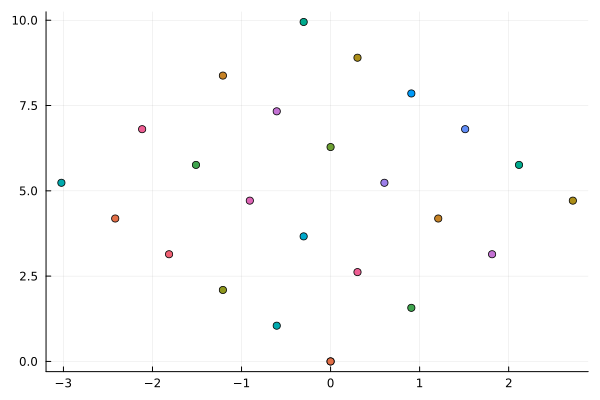

In [8]:
points=allowedq[1][1]*T1+allowedq[1][2]*T2
myplot=scatter([points[1]],[points[2]],set_aspect=:equal,legend=false)
for ja=1:Nx*Ny
    points=allowedq[ja][1]*T1+allowedq[ja][2]*T2
    scatter!([points[1]],[points[2]])
end
display(myplot)

In [9]:
isinteger(round(3.0000009,digits=5))

true

In [10]:

Fmatrix=Array{ComplexF64}(undef,Nx*Ny,Nx*Ny,dimension)
invmatrix=inv([g1T g3T])

for  jc in 1:Nx*Ny, jq in 1:Nx*Ny, je in 1:dimension
    k2qmeshT=[mod(allowedq[jc][1]+allowedq[jq][1],Nx),mod(allowedq[jc][2]+allowedq[jq][2],Ny)]
    qT=allowedq[jq]+wave[je]
    gk2qT=allowedq[jc]+qT-k2qmeshT

    qvec=(qT[1])*T1+(qT[2])*T2
    eta=1;
    #=
    if mod.(gk2qT,8)≠[0,0]
        eta=-1
    end
    =#
    if isinteger(round((invmatrix*gk2qT)[1]/2,digits=10))&& isinteger(round((invmatrix*gk2qT)[2]/2,digits=10))
    eta=-1
    end

   Fmatrix[jc,jq,je]=exp(-Lb^2/4*norm(qvec)^2)*eta*exp(im*π/(Nx*Ny)*(qT[1]*allowedq[jc][2]-qT[2]*allowedq[jc][1]))*exp(im*π/(Nx*Ny)*(gk2qT[1]*k2qmeshT[2]-gk2qT[2]*k2qmeshT[1]))
    
 
end



In [11]:
Vmatrix=Array{ComplexF64}(undef,Nx*Ny,Nx*Ny,Nx*Ny,Nx*Ny)


for ja in 1:Nx*Ny, jb in 1:Nx*Ny, jc in 1:Nx*Ny, jd in 1:Nx*Ny
Vmatrix[ja,jb,jc,jd]=0.0+0.0*im
end


for jc in 1:Nx*Ny,jd in 1:(jc-1),qmesh in 1:Nx*Ny
   
      k1mesh=[mod(allowedq[jc][1]+allowedq[qmesh][1],Nx),mod(allowedq[jc][2]+allowedq[qmesh][2],Ny)]
      k2mesh=[mod(allowedq[jd][1]-allowedq[qmesh][1],Nx),mod(allowedq[jd][2]-allowedq[qmesh][2],Ny)]
      k1mesh_pos=findfirst(item->item==k1mesh,allowedq)
      k2mesh_pos=findfirst(item->item==k2mesh,allowedq)
      if k1mesh_pos≠nothing && k2mesh_pos≠nothing 
        for qg in 1:length(wave)
            mqT=-1*allowedq[qmesh]-wave[qg]
            mqmesh=[mod(mqT[1],Nx),mod(mqT[2],Ny)]
            mqgT=mqT-mqmesh
            mqmesh_pos=findfirst(item->item==mqmesh,allowedq)
            mqg_pos=findfirst(item->item==mqgT,wave)
            qvec=(allowedq[qmesh][1]+wave[qg][1])*T1+(allowedq[qmesh][2]+wave[qg][2])*T2
            if mqg_pos≠nothing && mqmesh_pos≠nothing && norm(qvec)≠0
            Vmatrix[k1mesh_pos,k2mesh_pos,jc,jd]+=1/(Nx*Ny*Lb*norm(qvec))*Fmatrix[jc,qmesh,qg]*Fmatrix[jd,mqmesh_pos,mqg_pos]
            end
        end
     end
   
 end


To proceed, we need to get the correct non-zero matrix elements

In [12]:
 reduced_Vcol=ComplexF64[]
 reduced_Vcoor=Vector{Int64}[]

for i in 1:Nx*Ny, j in 1:i-1, k in 1:Nx*Ny, p in 1:k-1
 if abs(Vmatrix[i,j,k,p]-Vmatrix[j,i,k,p])>10^(-10)
 push!(reduced_Vcol,2*Vmatrix[i,j,k,p]-2*Vmatrix[j,i,k,p])
 push!(reduced_Vcoor,[i,j,k,p])
 end
end
println(reduced_Vcoor[1])
println(reduced_Vcol[1])


[2, 1, 2, 1]
-0.10652498228587887 + 1.2310211463377546e-20im


In [13]:
compare_Vcol=unique(round.(sort(abs.(reduced_Vcol)),digits=10))


76-element Vector{Float64}:
 0.0021485675
 0.0022600729
 0.0026762532
 0.0028554588
 0.0033775248
 0.0034256279
 0.0075861484
 0.0104693154
 0.0104700004
 0.011056647
 ⋮
 0.1043199079
 0.1065249823
 0.1146576101
 0.1149218623
 0.116513911
 0.1172369472
 0.1196515684
 0.1237898565
 0.1714068198

We now proceed to construct the many-body Hilbert space, MB_state is all the states, MB_state_can classifies them by their COM momentum.MB_state_integer also needs to be sorted

In [14]:
MB_state=collect(combinations(1:Nx*Ny,Nparticle))
 MB_state_can=Array{Any}(undef,Nx*Ny)
 MB_state_integer=Array{Any}(undef,Nx*Ny)

for ja=1:Nx*Ny
MB_state_can[ja]=Vector{Int64}[]
MB_state_integer[ja]=Int64[]
end

for ja=1:length(MB_state)
    QN=sum(allowedq[MB_state[ja]])
    QN_M=[mod(QN[1],Nx),mod(QN[2],Ny)]
    push!(MB_state_can[QN_M[1]+1+QN_M[2]*Nx],MB_state[ja])
    push!(MB_state_integer[QN_M[1]+1+QN_M[2]*Nx],sum(2 .^ (MB_state[ja].-1)))
end




for ja=1:Nx*Ny
  sortindex=sortperm(MB_state_integer[ja])
  MB_state_integer[ja][:]=MB_state_integer[ja][sortindex]
  MB_state_can[ja][:]=MB_state_can[ja][sortindex]
end




We now want to construct the sparse many-body matrix

In [15]:
 MB_spectrum=Array{Any}(undef,Nx*Ny)




 for ja=1:Nx*Ny
  matrix_index1=Int64[]
  matrix_index2=Int64[]
  matrix_value=ComplexF64[]


  for jb=1:length(MB_state_can[ja]), jc=1:length(reduced_Vcol)

     (sign,state)=Cann(reduced_Vcoor[jc][3],MB_state_integer[ja][jb],1)
     (sign,state)=Cann(reduced_Vcoor[jc][4],state,sign)
     (sign,state)=Cdag(reduced_Vcoor[jc][2],state,sign)
     (sign,state)=Cdag(reduced_Vcoor[jc][1],state,sign)

      state_index=searchsortedfirst(MB_state_integer[ja],state)
      
     if (state*sign)≠0 &&  (MB_state_integer[ja][state_index]==state) 
      push!(matrix_index1,state_index)
      push!(matrix_index2,jb)
      push!(matrix_value,sign*reduced_Vcol[jc]/2)
     end

  end
  
  for jb=1:length(MB_state_can[ja])
   
    push!(matrix_index1,jb)
    push!(matrix_index2,jb)
    push!(matrix_value,sum(eigenvalue_single[MB_state_can[ja][jb]]))

  end

  #MB_spectrum[ja]=eigvals(collect(sparse(matrix_index1,matrix_index2,matrix_value)))
  MB_spectrum[ja], ζ=eigs(sparse(matrix_index1,matrix_index2,matrix_value), nev=15,which=:SR)





end

print(MB_spectrum[2])




ComplexF64[2.0298748167774914 + 6.784802487090298e-18im, 2.033210047789102 - 7.85442633792827e-18im, 2.0383130010052803 + 1.1123107449143737e-17im, 2.045945910898171 - 2.1271839246140012e-18im, 2.0524048212431465 - 2.8183992753125646e-18im, 2.0527157604793187 - 1.5648640054416402e-17im, 2.0725838432799706 - 2.867711410675272e-19im, 2.078667354241082 + 1.555912695916712e-17im, 2.0899034794358546 + 1.402628460818667e-17im, 2.0915949025650615 + 2.000569330226111e-18im, 2.0951792749503637 - 1.524994980081022e-18im, 2.098200631451551 - 1.806162841650817e-18im, 2.0986888744821397 + 3.754246658384479e-18im, 2.100245192344182 - 8.296429964051404e-18im, 2.10146235692298 - 1.2430294425513114e-17im]

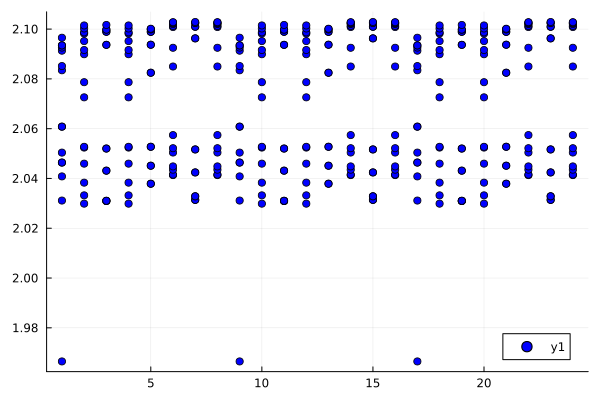

In [16]:
full_spectrum_x=Int64[]
full_spectrum_y=Float64[]
for ja=1:Nx*Ny, jb=1:15
push!(full_spectrum_x,ja)
push!(full_spectrum_y,real(MB_spectrum[ja][jb]))
end

myplot=scatter(full_spectrum_x,full_spectrum_y,mc=:blue)


In [17]:
MB_spectrum[10]

15-element Vector{ComplexF64}:
 2.0298748167774883 + 1.3930849695768353e-17im
 2.0332100477890993 - 7.992686576331044e-18im
 2.0383130010052697 + 7.06383143247841e-18im
 2.0459459108981726 - 1.3726080592161183e-17im
  2.052404821243138 - 3.8998541190269515e-18im
 2.0527157604793347 - 1.3436897950377974e-17im
 2.0725838432799386 - 3.164484068226126e-18im
  2.078667354241074 - 2.926484967855081e-18im
  2.089903479435844 + 9.446222461721224e-18im
  2.091594902565046 + 7.054161525707678e-18im
 2.0951792749503664 - 3.4323133221021613e-18im
  2.098200631451553 + 9.953608361207372e-18im
  2.098688874482154 + 1.4934148528433194e-17im
 2.1002451923441763 - 5.5711145383638914e-18im
 2.1014623569229722 + 1.8228218715063426e-18im

In [20]:
using JLD2
jldsave("landaulevel_4by6_spectrum.jld2",variable1=MB_spectrum)
